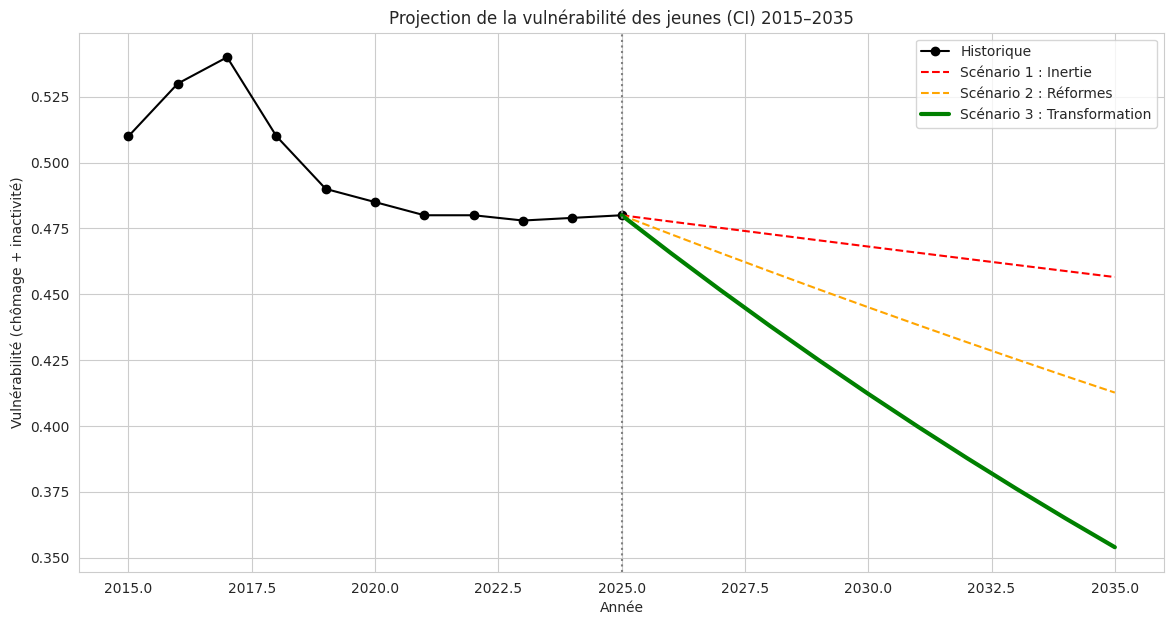

         Scénario      2035  Réduction (%)
0         Inertie  0.456533       0.048890
1        Réformes  0.412671       0.140270
2  Transformation  0.353964       0.262576


In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# DONNÉES DE BASE

years_hist = np.arange(2015, 2026)

vuln_hist = np.array([
    0.51, 0.53, 0.54, 0.51, 0.49,
    0.485, 0.48, 0.48, 0.478, 0.479, 0.48
])

years_proj = np.arange(2025, 2036)
v0 = vuln_hist[-1]

# 2. MODÈLE DE DÉCROISSANCE

def scenario(v0, years, rate):
    return [v0 * ((1 - rate) ** i) for i in range(len(years))]

# SCÉNARIOS

# Scénario 1 : inertie structurelle
scen1 = scenario(v0, years_proj, rate=0.005)

# Scénario 2 : réformes partielles
scen2 = scenario(v0, years_proj, rate=0.015)

# Scénario 3 : transformation structurelle
scen3 = scenario(v0, years_proj, rate=0.03)

# VISUALISATION

plt.figure(figsize=(14,7))
sns.set_style("whitegrid")

plt.plot(years_hist, vuln_hist,
         label="Historique", color="black", marker="o")

plt.plot(years_proj, scen1,
         "--", label="Scénario 1 : Inertie", color="red")

plt.plot(years_proj, scen2,
         "--", label="Scénario 2 : Réformes", color="orange")

plt.plot(years_proj, scen3,
         label="Scénario 3 : Transformation", color="green", linewidth=3)

plt.axvline(2025, color="gray", linestyle=":")

plt.title("Projection de la vulnérabilité des jeunes (CI) 2015–2035")
plt.xlabel("Année")
plt.ylabel("Vulnérabilité (chômage + inactivité)")
plt.legend()
plt.show()

# TABLEAU FINAL

df = pd.DataFrame({
    "Scénario": ["Inertie", "Réformes", "Transformation"],
    "2035": [scen1[-1], scen2[-1], scen3[-1]],
    "Réduction (%)": [
        (v0 - scen1[-1]) / v0,
        (v0 - scen2[-1]) / v0,
        (v0 - scen3[-1]) / v0
    ]
})

print(df)